# SISPS-EXP-SOH Environmental Test Chamber

Test chamber logs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

import darkdetect

plt.rcdefaults()

if darkdetect.isDark():
    plt.style.use("dark_background")

plt.rcParams.update(
    {
        "figure.dpi": 300,
        "figure.figsize": (8, 5),
    }
)

%config InlineBackend.figure_formats = ["svg"]

In [2]:
def load_etc_file(filepath) -> pd.DataFrame:
    """
    Load the ETC file and return a DataFrame.
    """
    df = pd.read_csv(
        filepath,
        sep=";",
        usecols=[
            "Date/Time",
            "CV1_SP",
            "CV1_AV",
        ],
    )

    return df


ETC_DATA_DIR = "../Data/ETC"
ETC_FILES = [
    file
    for file in os.listdir(ETC_DATA_DIR)
    if file.startswith("SERVICE-")  # Has a bit more data than "USER-"
    and file.endswith(".csv")
]

etc_data = pd.DataFrame()
for file in ETC_FILES:
    if file.endswith(".csv"):
        filepath = os.path.join(ETC_DATA_DIR, file)
        df = load_etc_file(filepath)
        etc_data = pd.concat([etc_data, df], ignore_index=True)

etc_data["Date/Time"] = pd.to_datetime(
    etc_data["Date/Time"],
    format="%Y.%m.%d %H:%M:%S",
)
etc_data = etc_data.sort_values(by="Date/Time")

# Decimate the data to 1 minute intervals
etc_data = etc_data.set_index("Date/Time").resample("1T").mean().reset_index()

/var/folders/3f/ct0r54cd0497vnq7h8jk96q40000gp/T/ipykernel_6574/2603438946.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  etc_data = etc_data.set_index("Date/Time").resample("1T").mean().reset_index()


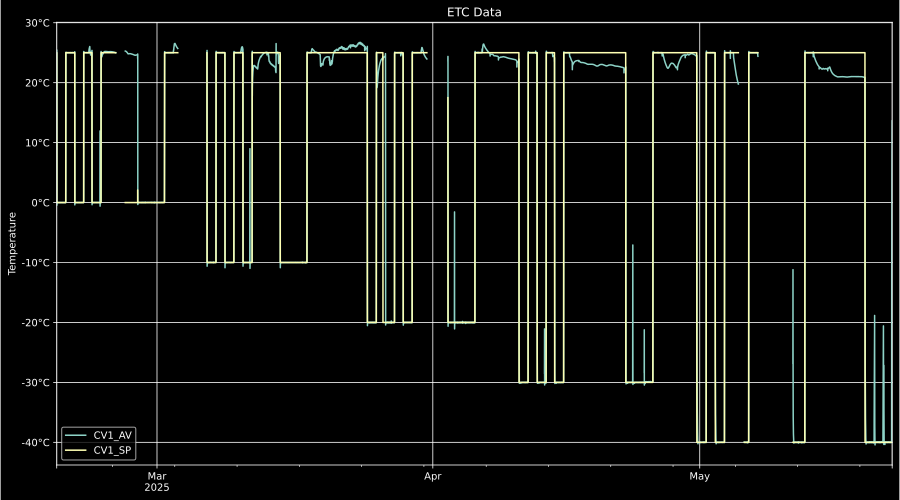

In [3]:
from matplotlib.ticker import FuncFormatter

ax = etc_data.plot(
    x="Date/Time",
    y=["CV1_AV", "CV1_SP"],
    title="ETC Data",
    xlabel="",
    ylabel="Temperature",
    grid=True,
    legend=True,
    figsize=(15, 8),
)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:.0f}°C")
)  # Format y-axis labels to show no decimal places